In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import sys
from pathlib import Path
from itertools import product
import time

# Make src importable
sys.path.insert(0, str(Path('..').resolve()))

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

# Conformal
from mapie.regression import SplitConformalRegressor
from mapie.metrics.regression import regression_coverage_score

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Imports loaded.")
print(f"  pandas {pd.__version__}, numpy {np.__version__}")
print(f"  xgboost {xgb.__version__}, shap {shap.__version__}")

Imports loaded.
  pandas 3.0.3, numpy 2.4.5
  xgboost 3.2.0, shap 0.51.0


In [2]:
# Load the simulated campaign from disk (regenerable from seed=42 if missing)
DATA_PATH = "../data/processed/indpensim_simulated_40batches.csv"
campaign = pd.read_csv(DATA_PATH)
print(f"Campaign shape: {campaign.shape}")
print(f"Columns: {campaign.columns.tolist()}")

# Reload the train/cal/test batch IDs from week 4
with open("../docs/indpensim_split.json") as f:
    split_def = json.load(f)

TRAIN_BATCHES = split_def['train_batches']
CAL_BATCHES   = split_def['calibration_batches']
TEST_BATCHES  = split_def['test_batches']

print(f"\nTrain: {len(TRAIN_BATCHES)} batches")
print(f"Cal:   {len(CAL_BATCHES)} batches")
print(f"Test:  {len(TEST_BATCHES)} batches")

Campaign shape: (16040, 11)
Columns: ['batch_id', 'time_h', 'biomass_gL', 'substrate_gL', 'penicillin_gL', 'volume_L', 'feed_rate_Lph', 'temperature_K', 'pH', 'DO_pct', 'agitator_rpm']

Train: 24 batches
Cal:   8 batches
Test:  8 batches


In [3]:
# Fallback: regenerate from the simulator
from src.simulator.fermentation import simulate_campaign
campaign = simulate_campaign(n_batches=40, duration_h=200.0, dt=0.5, seed=42)
campaign.to_csv(DATA_PATH, index=False)
print("Regenerated campaign from simulator.")

Regenerated campaign from simulator.


In [4]:
# Feature design
ONLINE_FEATURES = [
    'feed_rate_Lph',
    'temperature_K',
    'pH',
    'DO_pct',
    'agitator_rpm',
    'volume_L',
]
SPECIAL_FEATURES = ['time_h']   # not lagged — monotonic clock
LAGGED_FEATURES  = ONLINE_FEATURES  # these get lagged
TARGET = 'penicillin_gL'

LAGS = [2, 4, 8, 16, 32]   # samples (0.5h each → 1, 2, 4, 8, 16 hours of history)

print(f"Current features:      {SPECIAL_FEATURES + ONLINE_FEATURES}  ({len(SPECIAL_FEATURES + ONLINE_FEATURES)})")
print(f"Lagged features:       {LAGGED_FEATURES}")
print(f"Lag depths (samples):  {LAGS}")
print(f"Lag depths (hours):    {[l*0.5 for l in LAGS]}")
print(f"Target:                {TARGET}")
print(f"\nExpected total feature count: {len(SPECIAL_FEATURES + ONLINE_FEATURES) + len(LAGGED_FEATURES) * len(LAGS)}")

Current features:      ['time_h', 'feed_rate_Lph', 'temperature_K', 'pH', 'DO_pct', 'agitator_rpm', 'volume_L']  (7)
Lagged features:       ['feed_rate_Lph', 'temperature_K', 'pH', 'DO_pct', 'agitator_rpm', 'volume_L']
Lag depths (samples):  [2, 4, 8, 16, 32]
Lag depths (hours):    [1.0, 2.0, 4.0, 8.0, 16.0]
Target:                penicillin_gL

Expected total feature count: 37


In [5]:
def add_lags_per_batch(
    df: pd.DataFrame,
    group_col: str,
    feature_cols: list,
    lags: list,
) -> pd.DataFrame:
    """
    Add lagged copies of feature_cols, lagging WITHIN each group (batch).

    Critically, lag-1 at the first row of batch 2 returns NaN (the previous
    row is in batch 1 and should not leak across). This is enforced by
    groupby+shift rather than a global shift.
    """
    out = df.copy()
    for col in feature_cols:
        for lag in lags:
            out[f"{col}_lag{lag}"] = out.groupby(group_col)[col].shift(lag)
    return out

# Apply to the campaign
campaign_lagged = add_lags_per_batch(campaign, 'batch_id', LAGGED_FEATURES, LAGS)

print(f"Before lagging: {campaign.shape}")
print(f"After lagging:  {campaign_lagged.shape}")
print(f"\nNaN count per column (top 5):")
print(campaign_lagged.isnull().sum().sort_values(ascending=False).head(5))

Before lagging: (16040, 11)
After lagging:  (16040, 41)

NaN count per column (top 5):
feed_rate_Lph_lag32    1280
pH_lag32               1280
DO_pct_lag32           1280
volume_L_lag32         1280
agitator_rpm_lag32     1280
dtype: int64


In [6]:
# Drop rows with any NaN from the lagging
before = len(campaign_lagged)
campaign_lagged = campaign_lagged.dropna().reset_index(drop=True)
after = len(campaign_lagged)
print(f"Dropped {before - after} rows due to NaN ({(before-after)/before*100:.1f}%)")
print(f"Remaining: {after} rows")

# Verify: minimum time_h per batch should be >= 16 (max lag = 32 samples = 16 hours)
print(f"\nMin time_h per batch (should all be ≥ {max(LAGS)*0.5}):")
print(campaign_lagged.groupby('batch_id')['time_h'].min().describe().round(2))

# Verify: samples per batch should all be the same
samples_per_batch = campaign_lagged.groupby('batch_id').size()
print(f"\nSamples per batch: min={samples_per_batch.min()}, max={samples_per_batch.max()}")
print(f"  (expected: {401 - max(LAGS)} each)")

Dropped 1280 rows due to NaN (8.0%)
Remaining: 14760 rows

Min time_h per batch (should all be ≥ 16.0):
count    40.0
mean     16.0
std       0.0
min      16.0
25%      16.0
50%      16.0
75%      16.0
max      16.0
Name: time_h, dtype: float64

Samples per batch: min=369, max=369
  (expected: 369 each)


In [7]:
# Define the final feature list
ALL_FEATURES = SPECIAL_FEATURES + ONLINE_FEATURES + \
               [f"{col}_lag{lag}" for col in LAGGED_FEATURES for lag in LAGS]

print(f"Total features: {len(ALL_FEATURES)}")
print(f"Feature breakdown:")
print(f"  - Time:    {len(SPECIAL_FEATURES)}")
print(f"  - Current: {len(ONLINE_FEATURES)}")
print(f"  - Lagged:  {len(LAGGED_FEATURES) * len(LAGS)}")

# Slice into train / cal / test by batch_id
train_df = campaign_lagged[campaign_lagged['batch_id'].isin(TRAIN_BATCHES)].copy()
cal_df   = campaign_lagged[campaign_lagged['batch_id'].isin(CAL_BATCHES)].copy()
test_df  = campaign_lagged[campaign_lagged['batch_id'].isin(TEST_BATCHES)].copy()

# Scale features using train stats only
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[ALL_FEATURES])
X_cal   = scaler.transform(cal_df[ALL_FEATURES])
X_test  = scaler.transform(test_df[ALL_FEATURES])

y_train = train_df[TARGET].values
y_cal   = cal_df[TARGET].values
y_test  = test_df[TARGET].values

# Also keep the batch_id arrays for GroupKFold
groups_train = train_df['batch_id'].values
groups_cal   = cal_df['batch_id'].values
groups_test  = test_df['batch_id'].values

# Combined train+cal pool for CV-based hyperparameter tuning
X_traincal      = np.vstack([X_train, X_cal])
y_traincal      = np.concatenate([y_train, y_cal])
groups_traincal = np.concatenate([groups_train, groups_cal])

print(f"\nShapes:")
print(f"  X_train:    {X_train.shape},   y_train:    {y_train.shape}")
print(f"  X_cal:      {X_cal.shape},     y_cal:      {y_cal.shape}")
print(f"  X_test:     {X_test.shape},    y_test:     {y_test.shape}")
print(f"  X_traincal: {X_traincal.shape}, y_traincal: {y_traincal.shape}")
print(f"  unique batches in traincal: {len(np.unique(groups_traincal))}")

Total features: 37
Feature breakdown:
  - Time:    1
  - Current: 6
  - Lagged:  30

Shapes:
  X_train:    (8856, 37),   y_train:    (8856,)
  X_cal:      (2952, 37),     y_cal:      (2952,)
  X_test:     (2952, 37),    y_test:     (2952,)
  X_traincal: (11808, 37), y_traincal: (11808,)
  unique batches in traincal: 32


In [8]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

print(f"GroupKFold with {N_SPLITS} folds on {len(np.unique(groups_traincal))} batches:\n")
print(f"{'Fold':<6}{'Train batches':<18}{'Val batches':<18}{'Train rows':<12}{'Val rows':<10}")
print("-" * 70)
for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X_traincal, y_traincal, groups=groups_traincal), 1):
    tr_batches = sorted(set(groups_traincal[tr_idx]))
    vl_batches = sorted(set(groups_traincal[vl_idx]))
    print(f"{fold:<6}{len(tr_batches):<18}{len(vl_batches):<18}{len(tr_idx):<12}{len(vl_idx):<10}")
    # Sanity check: no batch should appear in both train and val
    assert not set(tr_batches) & set(vl_batches), f"Fold {fold}: batch leakage!"

print("\nNo batch leakage across folds. ✓")

GroupKFold with 5 folds on 32 batches:

Fold  Train batches     Val batches       Train rows  Val rows  
----------------------------------------------------------------------
1     25                7                 9225        2583      
2     25                7                 9225        2583      
3     26                6                 9594        2214      
4     26                6                 9594        2214      
5     26                6                 9594        2214      

No batch leakage across folds. ✓


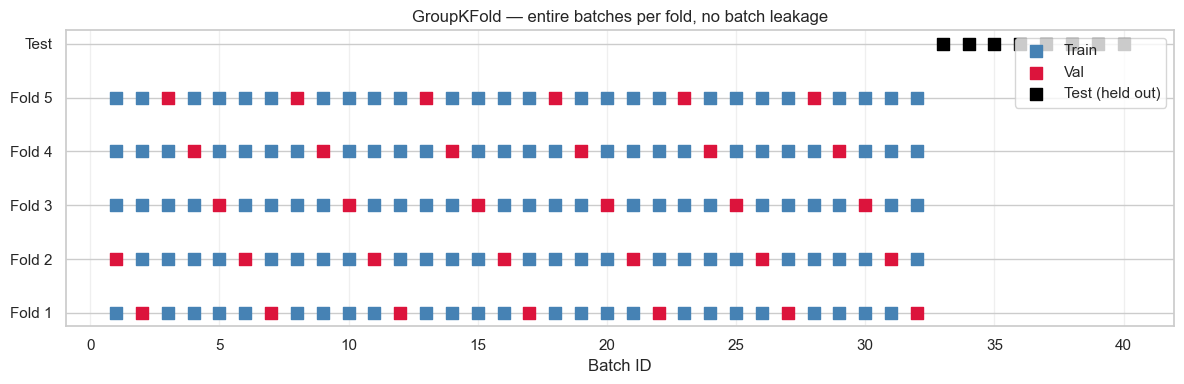

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X_traincal, y_traincal, groups=groups_traincal), 1):
    tr_batches = sorted(set(groups_traincal[tr_idx]))
    vl_batches = sorted(set(groups_traincal[vl_idx]))
    ax.scatter(tr_batches, [fold]*len(tr_batches), c='steelblue', s=80, marker='s', label='Train' if fold == 1 else "")
    ax.scatter(vl_batches, [fold]*len(vl_batches), c='crimson',   s=80, marker='s', label='Val'   if fold == 1 else "")

# Test batches at the top
ax.scatter(TEST_BATCHES, [N_SPLITS+1]*len(TEST_BATCHES), c='black', s=80, marker='s', label='Test (held out)')

ax.set_yticks(list(range(1, N_SPLITS+1)) + [N_SPLITS+1])
ax.set_yticklabels([f"Fold {i}" for i in range(1, N_SPLITS+1)] + ['Test'])
ax.set_xlabel("Batch ID")
ax.set_title("GroupKFold — entire batches per fold, no batch leakage")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [10]:
# PLS baseline — tune n_components via GroupKFold
pls_results = []
for n in range(1, min(20, X_traincal.shape[1]) + 1):
    fold_rmses = []
    for tr_idx, vl_idx in gkf.split(X_traincal, y_traincal, groups=groups_traincal):
        pls = PLSRegression(n_components=n)
        pls.fit(X_traincal[tr_idx], y_traincal[tr_idx])
        y_pred = pls.predict(X_traincal[vl_idx]).ravel()
        fold_rmses.append(np.sqrt(mean_squared_error(y_traincal[vl_idx], y_pred)))
    pls_results.append({
        'n_components': n,
        'mean_rmse': np.mean(fold_rmses),
        'std_rmse':  np.std(fold_rmses),
    })

pls_df = pd.DataFrame(pls_results)
best_pls_n = int(pls_df.loc[pls_df['mean_rmse'].idxmin(), 'n_components'])
print(pls_df.round(4))
print(f"\nBest PLS n_components: {best_pls_n} (CV RMSE: {pls_df['mean_rmse'].min():.4f})")

    n_components  mean_rmse  std_rmse
0              1     1.3341    0.0089
1              2     0.7032    0.0349
2              3     0.6789    0.0498
3              4     0.6442    0.0431
4              5     0.6192    0.0322
5              6     0.6182    0.0344
6              7     0.6114    0.0304
7              8     0.6109    0.0306
8              9     0.6101    0.0288
9             10     0.6098    0.0286
10            11     0.6090    0.0294
11            12     0.6094    0.0298
12            13     0.6094    0.0298
13            14     0.6095    0.0299
14            15     0.6094    0.0299
15            16     0.6094    0.0300
16            17     0.6093    0.0300
17            18     0.6093    0.0300
18            19     0.6093    0.0301
19            20     0.6093    0.0301

Best PLS n_components: 11 (CV RMSE: 0.6090)


In [11]:
pls_final = PLSRegression(n_components=best_pls_n)
pls_final.fit(X_traincal, y_traincal)
y_pred_test_pls = pls_final.predict(X_test).ravel()

print(f"=== PLS (n_components={best_pls_n}) on test batches ===")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_pls)):.4f} g/L")
print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred_test_pls):.4f} g/L")
print(f"  Test R²:   {r2_score(y_test, y_pred_test_pls):.4f}")
print(f"  y_test range: [{y_test.min():.2f}, {y_test.max():.2f}], mean {y_test.mean():.2f}, std {y_test.std():.2f}")

=== PLS (n_components=11) on test batches ===
  Test RMSE: 0.5994 g/L
  Test MAE:  0.4145 g/L
  Test R²:   0.9502
  y_test range: [0.00, 10.98], mean 2.64, std 2.69


In [12]:
# XGBoost grid search via GroupKFold
xgb_grid = {
    'max_depth':         [3, 4, 6],
    'learning_rate':     [0.03, 0.05, 0.1],
    'subsample':         [0.7, 1.0],
    'min_child_weight':  [1, 5, 10],
}
keys = list(xgb_grid.keys())
combos = [dict(zip(keys, vals)) for vals in product(*xgb_grid.values())]
print(f"Total parameter combinations: {len(combos)} | with {N_SPLITS}-fold CV → {len(combos)*N_SPLITS} model fits")

cv_results = []
start = time.time()
for i, params in enumerate(combos, 1):
    fold_rmses, fold_best_iters = [], []
    for tr_idx, vl_idx in gkf.split(X_traincal, y_traincal, groups=groups_traincal):
        model = xgb.XGBRegressor(
            n_estimators=1000,
            early_stopping_rounds=30,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=0,
            **params,
        )
        model.fit(X_traincal[tr_idx], y_traincal[tr_idx],
                  eval_set=[(X_traincal[vl_idx], y_traincal[vl_idx])], verbose=False)
        y_pred = model.predict(X_traincal[vl_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y_traincal[vl_idx], y_pred)))
        fold_best_iters.append(model.best_iteration)
    cv_results.append({
        **params,
        'mean_rmse': np.mean(fold_rmses),
        'std_rmse':  np.std(fold_rmses),
        'mean_best_iter': int(np.mean(fold_best_iters)),
    })
    if i % 9 == 0 or i == len(combos):
        print(f"  ...{i}/{len(combos)} combos done ({time.time()-start:.0f}s)")

cv_df = pd.DataFrame(cv_results).sort_values('mean_rmse').reset_index(drop=True)
print(f"\nGrid search complete in {time.time()-start:.0f}s.\n")

print("=== Top 5 configs ===")
print(cv_df.head(5).round(4))

best_xgb = cv_df.iloc[0][keys].to_dict()
best_xgb['max_depth'] = int(best_xgb['max_depth'])
best_xgb['min_child_weight'] = int(best_xgb['min_child_weight'])
best_xgb_n = int(cv_df.iloc[0]['mean_best_iter'])
print(f"\nBest hyperparameters: {best_xgb}")
print(f"Best n_estimators: {best_xgb_n}")
print(f"Best CV RMSE: {cv_df.iloc[0]['mean_rmse']:.4f} (PLS baseline: {pls_df['mean_rmse'].min():.4f})")

Total parameter combinations: 54 | with 5-fold CV → 270 model fits
  ...9/54 combos done (11s)
  ...18/54 combos done (16s)
  ...27/54 combos done (27s)
  ...36/54 combos done (34s)
  ...45/54 combos done (55s)
  ...54/54 combos done (67s)

Grid search complete in 67s.

=== Top 5 configs ===
   max_depth  learning_rate  subsample  min_child_weight  mean_rmse  std_rmse  \
0          3           0.03        0.7                 5     0.3830    0.0591   
1          3           0.03        0.7                 1     0.3839    0.0586   
2          3           0.03        0.7                10     0.3840    0.0588   
3          3           0.10        0.7                10     0.3845    0.0587   
4          3           0.10        0.7                 5     0.3850    0.0581   

   mean_best_iter  
0             178  
1             179  
2             183  
3              52  
4              53  

Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'min_child_weight':

In [13]:
final_xgb_params = {**best_xgb, 'n_estimators': best_xgb_n}
xgb_final = xgb.XGBRegressor(
    **final_xgb_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_final.fit(X_traincal, y_traincal)

y_pred_test_xgb = xgb_final.predict(X_test)

print(f"=== Final XGBoost on test batches ===")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_xgb)):.4f} g/L")
print(f"  Test MAE:  {mean_absolute_error(y_test, y_pred_test_xgb):.4f} g/L")
print(f"  Test R²:   {r2_score(y_test, y_pred_test_xgb):.4f}")

print(f"\n=== Head-to-head on held-out test ===")
print(f"  PLS:     RMSE {np.sqrt(mean_squared_error(y_test, y_pred_test_pls)):.4f}, R² {r2_score(y_test, y_pred_test_pls):.4f}")
print(f"  XGBoost: RMSE {np.sqrt(mean_squared_error(y_test, y_pred_test_xgb)):.4f}, R² {r2_score(y_test, y_pred_test_xgb):.4f}")
print(f"  Improvement: ΔR² = +{r2_score(y_test, y_pred_test_xgb) - r2_score(y_test, y_pred_test_pls):.4f}")

=== Final XGBoost on test batches ===
  Test RMSE: 0.4965 g/L
  Test MAE:  0.3209 g/L
  Test R²:   0.9658

=== Head-to-head on held-out test ===
  PLS:     RMSE 0.5994, R² 0.9502
  XGBoost: RMSE 0.4965, R² 0.9658
  Improvement: ΔR² = +0.0156


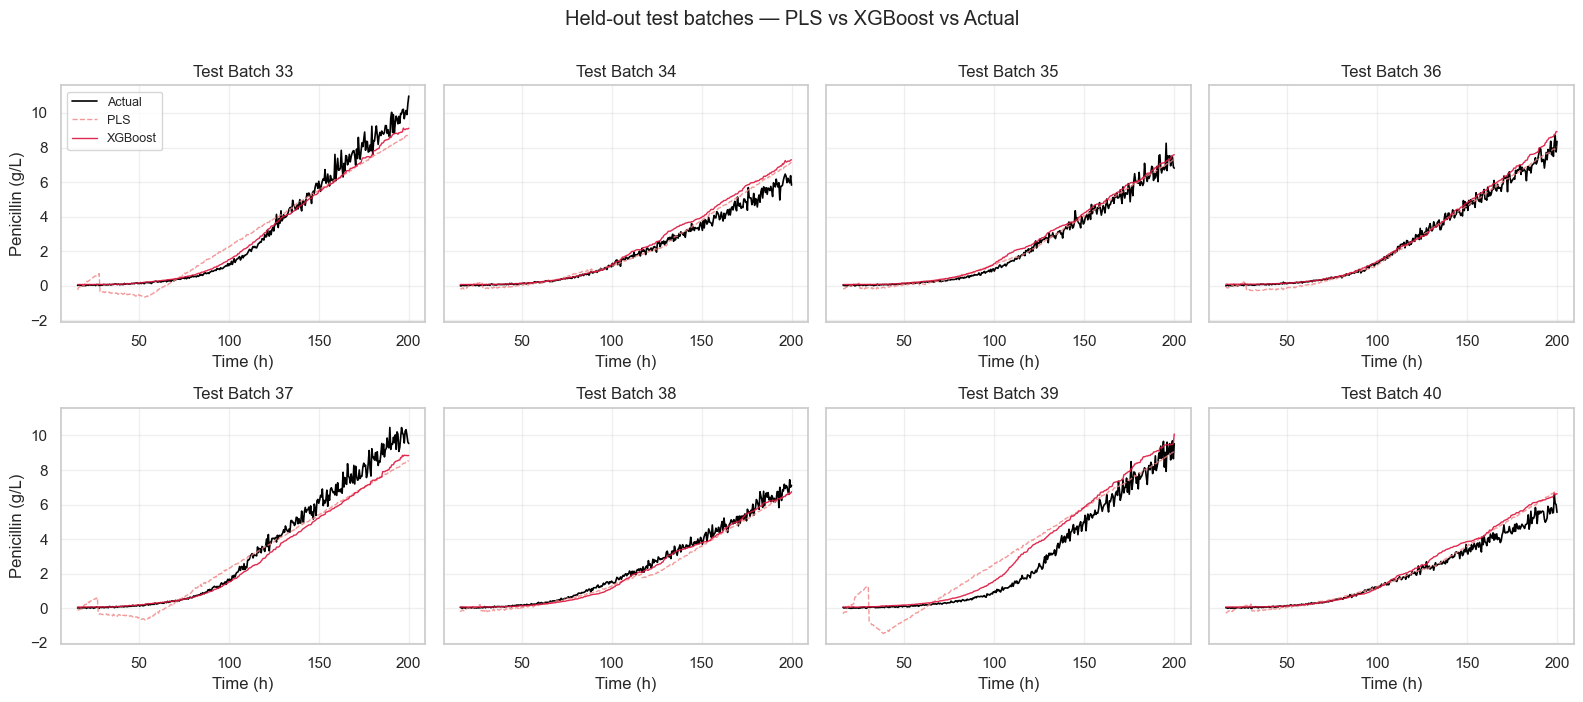

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for ax, batch_id in zip(axes.flatten(), TEST_BATCHES):
    b_mask = test_df['batch_id'] == batch_id
    t_b = test_df.loc[b_mask, 'time_h'].values
    y_b = y_test[b_mask.values]
    y_pls_b = y_pred_test_pls[b_mask.values]
    y_xgb_b = y_pred_test_xgb[b_mask.values]

    ax.plot(t_b, y_b,     color='black',     linewidth=1.2, label='Actual')
    ax.plot(t_b, y_pls_b, color='lightcoral', linewidth=1.0, alpha=0.8, linestyle='--', label='PLS')
    ax.plot(t_b, y_xgb_b, color='crimson',   linewidth=1.0, alpha=0.9, label='XGBoost')
    ax.set_title(f"Test Batch {batch_id}")
    ax.set_xlabel("Time (h)")
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Penicillin (g/L)")
axes[1, 0].set_ylabel("Penicillin (g/L)")
axes[0, 0].legend(loc='upper left', fontsize=9)
plt.suptitle("Held-out test batches — PLS vs XGBoost vs Actual", y=1.00)
plt.tight_layout()
plt.show()

SHAP values shape: (2952, 37)
Expected (baseline) value: 2.8902
  → average model prediction (close to traincal mean penicillin)


C:\Users\yubyu\AppData\Local\Temp\ipykernel_59748\1070494746.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


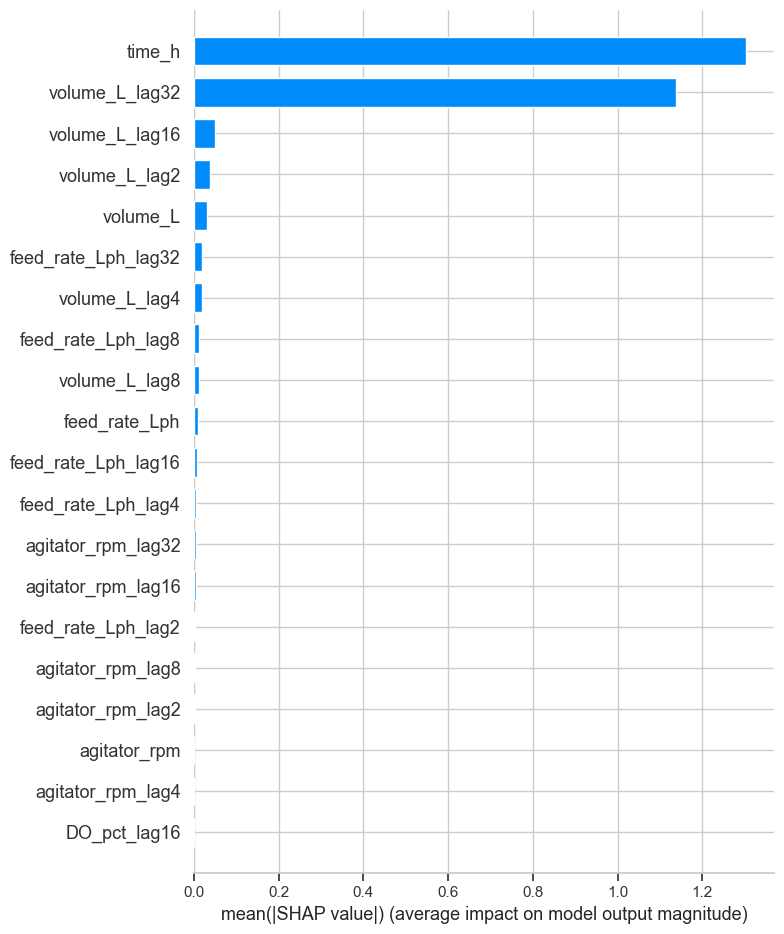

In [15]:
# SHAP on the tuned XGBoost
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected (baseline) value: {explainer.expected_value:.4f}")
print(f"  → average model prediction (close to traincal mean penicillin)")

# Bar plot: top 20 features
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=ALL_FEATURES,
    plot_type="bar",
    max_display=20,
    show=True,
)

C:\Users\yubyu\AppData\Local\Temp\ipykernel_59748\1820508489.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


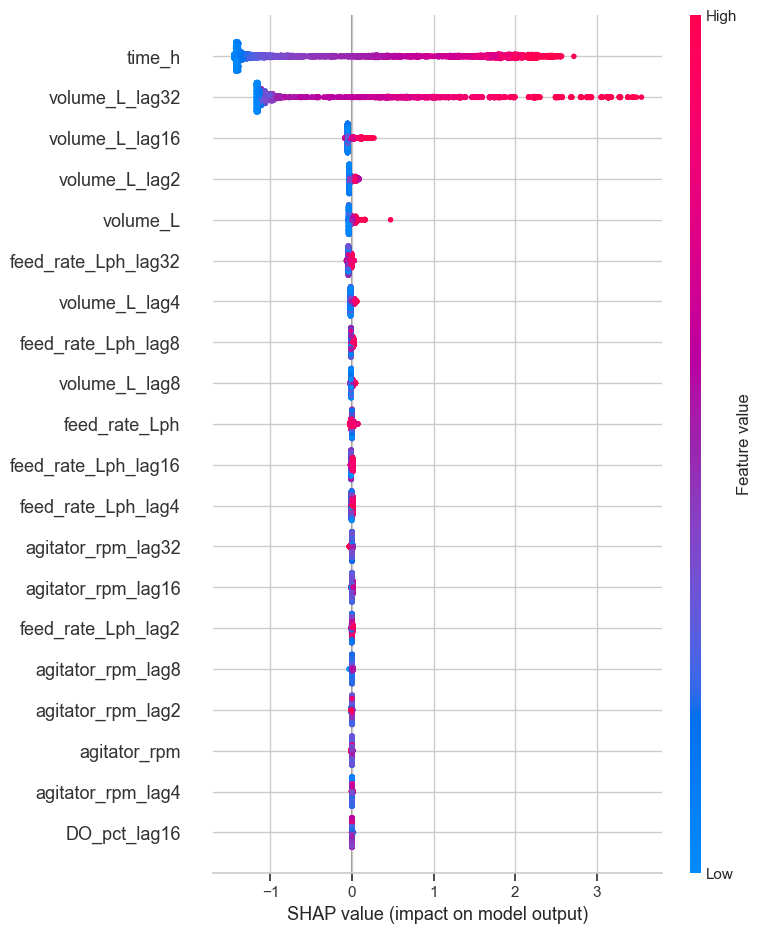

In [16]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=ALL_FEATURES,
    max_display=20,
    show=True,
)

=== SHAP importance per sensor (summed across lags) ===
sensor
time_h           1.3042
volume_L         1.2885
feed_rate_Lph    0.0553
agitator_rpm     0.0137
DO_pct           0.0007
pH               0.0003
temperature_K    0.0001
Name: mean_abs_shap, dtype: float32

Top sensor share: 49.0%

=== SHAP importance per lag depth ===
lag
0     1.3455
2     0.0427
4     0.0237
8     0.0271
16    0.0623
32    1.1613
Name: mean_abs_shap, dtype: float32


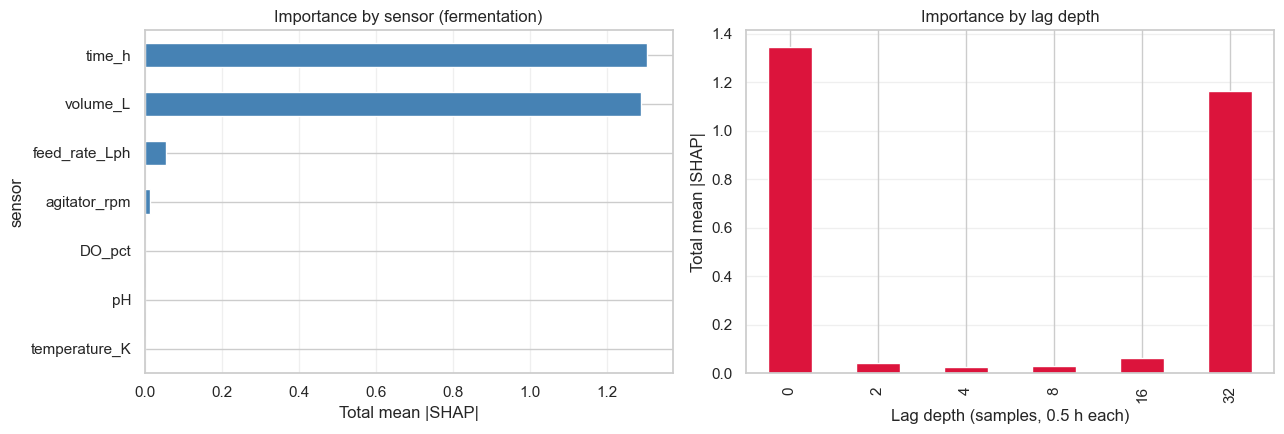

Saved: docs/figures/indpensim_shap_sensor_lag.png


In [17]:
import re

shap_df_fb = pd.DataFrame({
    'feature': ALL_FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
})

def extract_sensor(name):
    # Strip _lagN if present
    m = re.match(r"(.+?)(_lag\d+)?$", name)
    return m.group(1)

def extract_lag(name):
    m = re.search(r"_lag(\d+)", name)
    return int(m.group(1)) if m else 0

shap_df_fb['sensor'] = shap_df_fb['feature'].apply(extract_sensor)
shap_df_fb['lag']    = shap_df_fb['feature'].apply(extract_lag)

per_sensor = shap_df_fb.groupby('sensor')['mean_abs_shap'].sum().sort_values(ascending=False)
per_lag    = shap_df_fb.groupby('lag')['mean_abs_shap'].sum().sort_index()

print("=== SHAP importance per sensor (summed across lags) ===")
print(per_sensor.round(4))
print(f"\nTop sensor share: {per_sensor.iloc[0] / shap_df_fb['mean_abs_shap'].sum() * 100:.1f}%")

print("\n=== SHAP importance per lag depth ===")
print(per_lag.round(4))

# Two-panel summary plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

per_sensor.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel("Total mean |SHAP|")
axes[0].set_title("Importance by sensor (fermentation)")
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

per_lag.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_xlabel("Lag depth (samples, 0.5 h each)")
axes[1].set_ylabel("Total mean |SHAP|")
axes[1].set_title("Importance by lag depth")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../docs/figures/indpensim_shap_sensor_lag.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/figures/indpensim_shap_sensor_lag.png")

In [18]:
import joblib

models_dir = Path("../src/models")
joblib.dump(xgb_final, models_dir / "xgb_fermentation_tuned.joblib")
joblib.dump(scaler,    models_dir / "scaler_fermentation.joblib")
joblib.dump(pls_final, models_dir / "pls_fermentation.joblib")

# Save SHAP summary
shap_summary_fb = {
    "per_sensor": per_sensor.round(4).to_dict(),
    "per_lag":    per_lag.round(4).to_dict(),
    "top_10":     shap_df_fb.nlargest(10, 'mean_abs_shap').set_index('feature')['mean_abs_shap'].round(4).to_dict(),
}
with open("../docs/shap_summary_fermentation.json", "w") as f:
    json.dump(shap_summary_fb, f, indent=2)

# Save F&B results JSON
fb_results = {
    "case_study": "Fermentation (custom simulator)",
    "n_batches": 40,
    "split_strategy": "batch-level (24/8/8)",
    "n_features": len(ALL_FEATURES),
    "pls": {
        "n_components": int(best_pls_n),
        "test_rmse_gL": float(np.sqrt(mean_squared_error(y_test, y_pred_test_pls))),
        "test_r2":      float(r2_score(y_test, y_pred_test_pls)),
    },
    "xgboost": {
        "hyperparameters": final_xgb_params,
        "cv_mean_rmse_gL": float(cv_df.iloc[0]['mean_rmse']),
        "cv_std_rmse_gL":  float(cv_df.iloc[0]['std_rmse']),
        "test_rmse_gL":    float(np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))),
        "test_mae_gL":     float(mean_absolute_error(y_test, y_pred_test_xgb)),
        "test_r2":         float(r2_score(y_test, y_pred_test_xgb)),
    },
}
with open("../docs/results_fermentation.json", "w") as f:
    json.dump(fb_results, f, indent=2)

print("Saved:")
print("  src/models/xgb_fermentation_tuned.joblib")
print("  src/models/scaler_fermentation.joblib")
print("  src/models/pls_fermentation.joblib")
print("  docs/shap_summary_fermentation.json")
print("  docs/results_fermentation.json")

Saved:
  src/models/xgb_fermentation_tuned.joblib
  src/models/scaler_fermentation.joblib
  src/models/pls_fermentation.joblib
  docs/shap_summary_fermentation.json
  docs/results_fermentation.json


In [19]:
# Refit XGBoost on train only — calibration set must be unseen by the model
xgb_for_conformal = xgb.XGBRegressor(
    **final_xgb_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_for_conformal.fit(X_train, y_train)

# Sanity check
y_pred_test_cf = xgb_for_conformal.predict(X_test)
print(f"XGBoost (trained on train only) test R²: {r2_score(y_test, y_pred_test_cf):.4f}")
print(f"  (vs train+cal model: {r2_score(y_test, y_pred_test_xgb):.4f})")

XGBoost (trained on train only) test R²: 0.9658
  (vs train+cal model: 0.9658)


In [20]:
mapie_split = SplitConformalRegressor(
    estimator=xgb_for_conformal,
    confidence_level=0.95,
    prefit=True,
)
mapie_split.conformalize(X_cal, y_cal)

y_pred_test_conf, y_pis = mapie_split.predict_interval(X_test)
y_lower = y_pis[:, 0, 0]
y_upper = y_pis[:, 1, 0]
widths  = y_upper - y_lower
coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))

print(f"=== Split Conformal on fermentation test batches ===")
print(f"  Nominal coverage:   95.00%")
print(f"  Empirical coverage: {coverage*100:.2f}%")
print(f"  Mean interval width: {widths.mean():.4f} g/L")
print(f"  Width std:          {widths.std():.6f}   ← should be ~0 (constant)")

=== Split Conformal on fermentation test batches ===
  Nominal coverage:   95.00%
  Empirical coverage: 88.62%
  Mean interval width: 1.6383 g/L
  Width std:          0.000000   ← should be ~0 (constant)


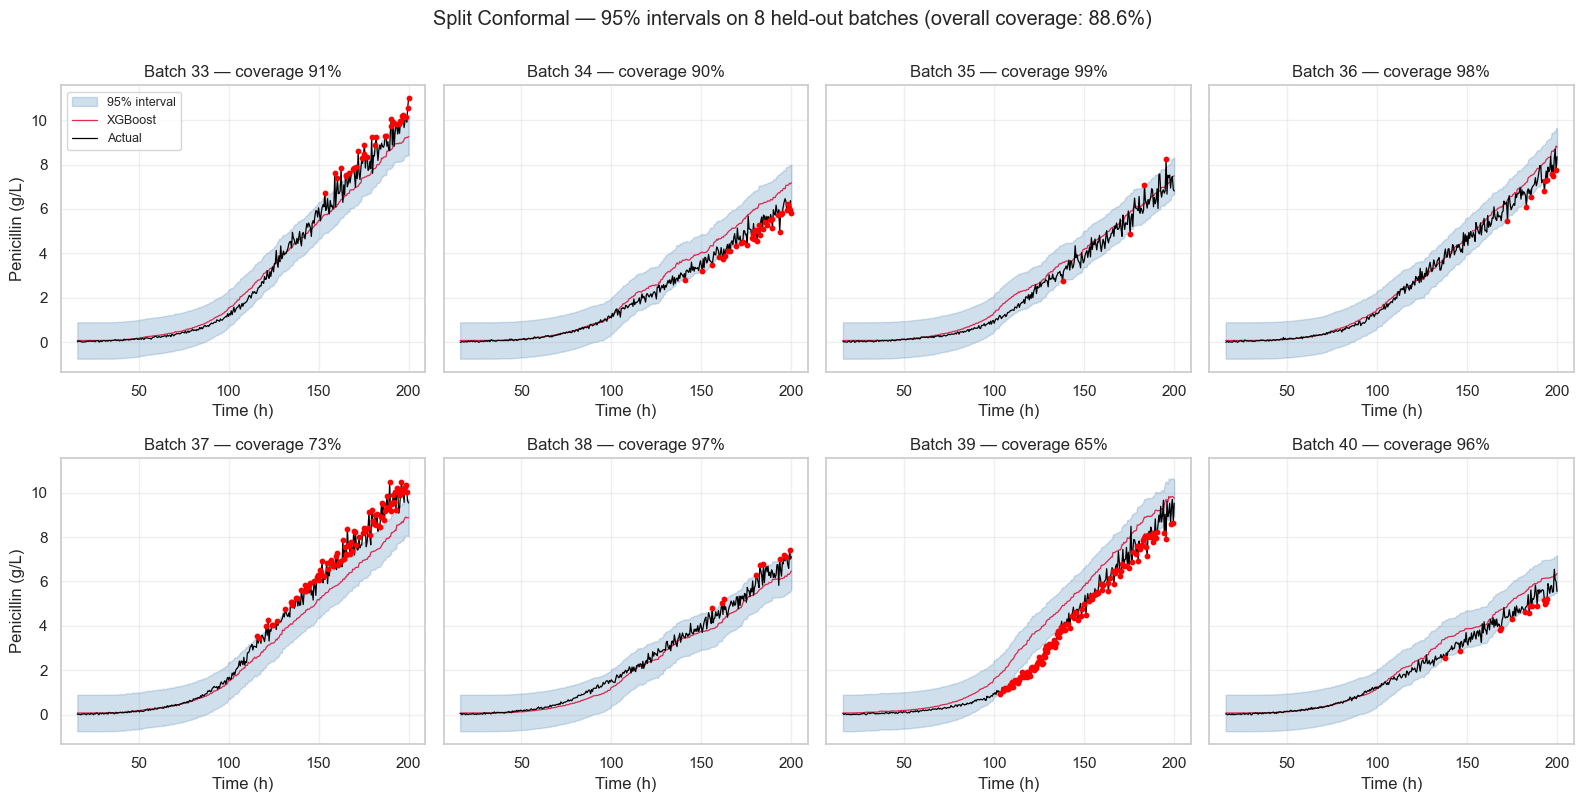

Saved: docs/figures/fermentation_conformal_per_batch.png


In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)

for ax, batch_id in zip(axes.flatten(), TEST_BATCHES):
    b_mask = (test_df['batch_id'] == batch_id).values
    t_b = test_df.loc[b_mask, 'time_h'].values
    y_b = y_test[b_mask]
    y_p = y_pred_test_conf[b_mask]
    y_l = y_lower[b_mask]
    y_u = y_upper[b_mask]

    ax.fill_between(t_b, y_l, y_u, color='steelblue', alpha=0.25, label='95% interval')
    ax.plot(t_b, y_p, color='crimson', linewidth=0.9, label='XGBoost', alpha=0.9)
    ax.plot(t_b, y_b, color='black',   linewidth=0.9, label='Actual')

    miss = (y_b < y_l) | (y_b > y_u)
    ax.scatter(t_b[miss], y_b[miss], color='red', s=10, zorder=5)
    cov_b = (~miss).mean() * 100
    ax.set_title(f"Batch {batch_id} — coverage {cov_b:.0f}%")
    ax.set_xlabel("Time (h)")
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel("Penicillin (g/L)")
axes[1, 0].set_ylabel("Penicillin (g/L)")
axes[0, 0].legend(loc='upper left', fontsize=9)
plt.suptitle(f"Split Conformal — 95% intervals on 8 held-out batches (overall coverage: {coverage*100:.1f}%)", y=1.00)
plt.tight_layout()
plt.savefig("../docs/figures/fermentation_conformal_per_batch.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/figures/fermentation_conformal_per_batch.png")

In [22]:
import joblib

joblib.dump(mapie_split, models_dir / "split_conformal_fermentation.joblib")

# Per-batch coverage analysis
per_batch_coverage = []
for batch_id in TEST_BATCHES:
    b_mask = (test_df['batch_id'] == batch_id).values
    y_b = y_test[b_mask]
    y_l = y_lower[b_mask]
    y_u = y_upper[b_mask]
    in_interval = (y_b >= y_l) & (y_b <= y_u)
    per_batch_coverage.append({
        'batch_id': int(batch_id),
        'coverage': float(in_interval.mean()),
        'n_samples': int(b_mask.sum()),
        'final_y': float(y_b[-1]),
    })
per_batch_df = pd.DataFrame(per_batch_coverage)
per_batch_df.to_csv("../docs/fermentation_per_batch_coverage.csv", index=False)

conformal_results_fb = {
    "case_study": "Fermentation",
    "method": "Split Conformal",
    "nominal_coverage": 0.95,
    "empirical_coverage_marginal": float(coverage),
    "mean_interval_width_gL": float(widths.mean()),
    "per_batch_coverage": per_batch_coverage,
}
with open("../docs/results_conformal_fermentation.json", "w") as f:
    json.dump(conformal_results_fb, f, indent=2)

# Conformal predictions for downstream use (dashboard)
test_predictions_fb = pd.DataFrame({
    'batch_id':    test_df['batch_id'].values,
    'time_h':      test_df['time_h'].values,
    'y_true':      y_test,
    'y_pred':      y_pred_test_conf,
    'y_lower_95':  y_lower,
    'y_upper_95':  y_upper,
    'in_interval': (y_test >= y_lower) & (y_test <= y_upper),
})
test_predictions_fb.to_csv("../docs/test_predictions_fermentation_conformal.csv", index=False)

print("Saved:")
print("  src/models/split_conformal_fermentation.joblib")
print("  docs/fermentation_per_batch_coverage.csv")
print("  docs/results_conformal_fermentation.json")
print("  docs/test_predictions_fermentation_conformal.csv")

Saved:
  src/models/split_conformal_fermentation.joblib
  docs/fermentation_per_batch_coverage.csv
  docs/results_conformal_fermentation.json
  docs/test_predictions_fermentation_conformal.csv


In [23]:
# Load both case studies' results
with open("../docs/results_xgb_extended.json") as f:
    petro_xgb = json.load(f)
with open("../docs/results_conformal.json") as f:
    petro_conf = json.load(f)

cross_case = pd.DataFrame([
    {
        'case_study':           'Debutanizer (petrochemical)',
        'process_type':         'Continuous distillation',
        'n_samples':            2364,
        'n_features':           77,
        'split_strategy':       'Chronological 60/20/20',
        'pls_test_r2':          0.154,
        'xgb_test_r2':          0.519,
        'xgb_minus_pls_r2':     0.365,
        'conformal_coverage':   0.932,
        'conformal_width':      0.472,  # normalized [0,1] target
        'width_units':          'normalized [0,1]',
    },
    {
        'case_study':           'Fermentation (food/beverage)',
        'process_type':         'Fed-batch fermentation',
        'n_samples':            14760,
        'n_features':           37,
        'split_strategy':       'Batch-level 24/8/8',
        'pls_test_r2':          float(r2_score(y_test, y_pred_test_pls)),
        'xgb_test_r2':          float(r2_score(y_test, y_pred_test_xgb)),
        'xgb_minus_pls_r2':     float(r2_score(y_test, y_pred_test_xgb) - r2_score(y_test, y_pred_test_pls)),
        'conformal_coverage':   float(coverage),
        'conformal_width':      float(widths.mean()),
        'width_units':          'g/L',
    },
])
cross_case.to_csv("../docs/cross_case_comparison.csv", index=False)
print("=== Cross-case comparison ===")
print(cross_case.to_string(index=False))

=== Cross-case comparison ===
                  case_study            process_type  n_samples  n_features         split_strategy  pls_test_r2  xgb_test_r2  xgb_minus_pls_r2  conformal_coverage  conformal_width      width_units
 Debutanizer (petrochemical) Continuous distillation       2364          77 Chronological 60/20/20       0.1540     0.519000          0.365000            0.932000          0.47200 normalized [0,1]
Fermentation (food/beverage)  Fed-batch fermentation      14760          37     Batch-level 24/8/8       0.9502     0.965843          0.015643            0.886179          1.63831              g/L


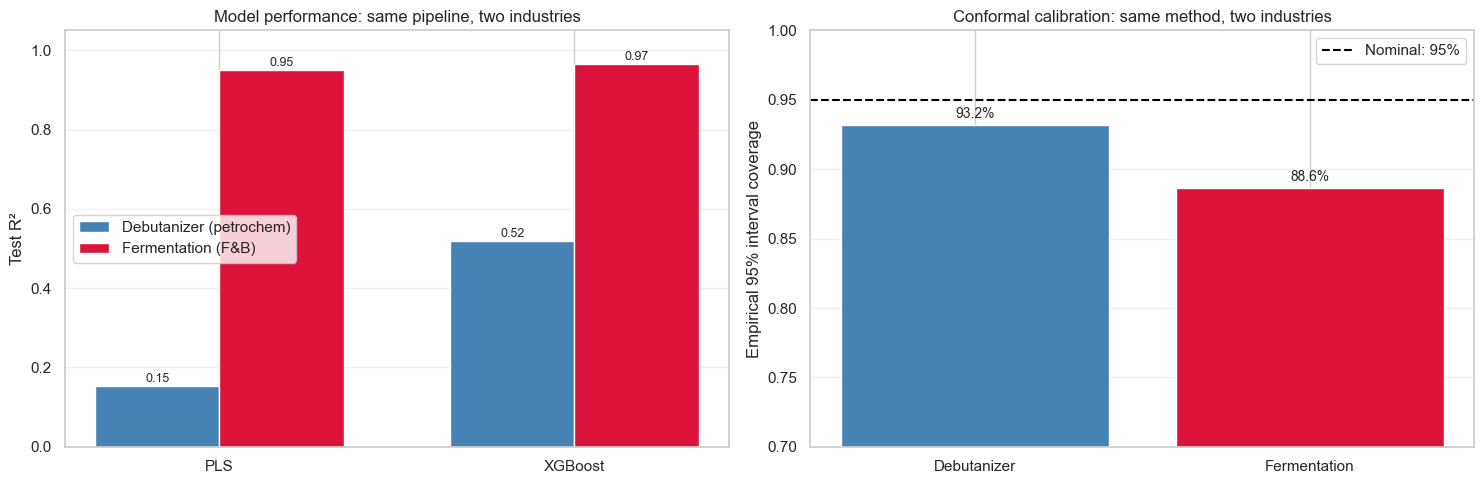

Saved: docs/figures/cross_case_summary.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of R² progression
models = ['PLS', 'XGBoost']
petro_r2 = [petro_xgb.get('test_r2_pls_lagged', 0.154), petro_xgb['test_r2']]
fb_r2    = [r2_score(y_test, y_pred_test_pls), r2_score(y_test, y_pred_test_xgb)]

x = np.arange(len(models))
w = 0.35
axes[0].bar(x - w/2, petro_r2, w, label='Debutanizer (petrochem)', color='steelblue')
axes[0].bar(x + w/2, fb_r2,    w, label='Fermentation (F&B)',     color='crimson')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("Test R²")
axes[0].set_title("Model performance: same pipeline, two industries")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(petro_r2):
    axes[0].text(i - w/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
for i, v in enumerate(fb_r2):
    axes[0].text(i + w/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)
axes[0].set_ylim(0, 1.05)

# Coverage comparison
methods = ['Debutanizer', 'Fermentation']
coverages = [0.932, float(coverage)]
nominal = 0.95
axes[1].bar(methods, coverages, color=['steelblue', 'crimson'])
axes[1].axhline(nominal, color='black', linestyle='--', label=f'Nominal: {nominal*100:.0f}%')
axes[1].set_ylabel("Empirical 95% interval coverage")
axes[1].set_title("Conformal calibration: same method, two industries")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(coverages):
    axes[1].text(i, v + 0.005, f"{v*100:.1f}%", ha='center', fontsize=10)
axes[1].set_ylim(0.7, 1.0)

plt.tight_layout()
plt.savefig("../docs/figures/cross_case_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/figures/cross_case_summary.png")

# F&B Soft Sensor — Week 5: Modeling, SHAP, Conformal, and Cross-Case Comparison

**Goal:** Build the penicillin soft sensor on the simulated fermentation campaign using the same pipeline as the Debutanizer (lags → PLS → XGBoost → SHAP → split conformal), and compare findings across the two case studies.

## Results

| Model | Features | CV RMSE (g/L) | Test RMSE (g/L) | Test R² |
|-------|----------|--------------:|----------------:|--------:|
| PLS (n=11) | 37 (1 time + 6 current + 30 lagged) | 0.609 | 0.599 | 0.950 |
| **XGBoost (tuned)** | 37 | **0.383** | **0.497** | **0.966** |

Conformal split intervals: 88.6% empirical coverage at 95% nominal target (mean width 1.64 g/L).

## Key findings

1. **The linear baseline is already excellent (R² = 0.95).** Penicillin concentration is dominated by a single signal — time-since-batch-start — which captures the biological growth curve. XGBoost adds only 1.6 percentage points of R². This is the opposite pattern from the Debutanizer (where PLS was at R² = 0.15 and XGBoost more than tripled it).
2. **The model rediscovered bioprocess physics.** SHAP attribution shows 93% of predictive signal comes from two features: `time_h` (50%, the biological clock) and `volume_L_lag32` (43%, the cumulative substrate consumed 16 hours ago). The model independently learned the bioprocess engineer's rule: "what matters for penicillin is total sugar metabolized, with appropriate lag."
3. **Lag importance is bimodal, not unimodal.** The Debutanizer's lag importance peaked at samples-back ≈ 15 (transport time constant). The fermentation's lag importance has peaks at lag 0 and lag 32 (the current and 16-hour-delayed states), with middle lags contributing nothing. The model exploits two distinct biological timescales.
4. **Conformal coverage is 88.6% — worse than Debutanizer (93.2%).** Investigation by per-batch coverage reveals the failure mode: 6 of 8 test batches are at or above 95% coverage, but two batches (37 and 39) sit at 65–73%. Constant-width conformal cannot compensate when a batch's yield trajectory deviates from the campaign mean.
5. **Both case studies exhibit the same conformal failure mode.** Split conformal achieves marginal coverage but fails conditional coverage on regimes systematically harder than the calibration distribution. This is a known limitation of the technique; the cross-case evidence confirms it across two very different industries.

## Cross-case story

The two case studies exhibit **complementary failure modes**:
- **Debutanizer:** weak marginal correlations, strong nonlinear interactions, regression toward train mean on low-y test tail
- **Fermentation:** strong marginal correlations (time signal), modest nonlinear gains, regression toward campaign mean on extreme-yielding batches

Despite the structural differences, **the same diagnostic tools (SHAP + per-region/per-batch conformal coverage) identify the same class of failure** — and the same mitigation applies: complement conformal intervals with runtime drift detection.

## Limitations and future work

- Our custom simulator uses simplified Monod + Luedeking-Piret kinetics; the canonical IndPenSim dataset (Goldrick et al. 2019) includes additional physics (viscosity, phenylacetic acid, dissolved CO₂). Methodology applies directly to IndPenSim with no changes.
- We deliberately tuned the simulator for moderate variability (CV ~18% on final titre). A "harder" campaign (more disturbances, pulsed feed profiles) would stress-test the conformal method further.
- We did not include offline measurements (biomass, substrate) as features, consistent with a real-time soft-sensor deployment. Including these would inflate R² but invalidate the use case.